# Pedestrian dead reckoning

Ziel dieses Notebooks ist die Kombination von Heading aus 260622_Heading.jpynb und der Schritterkennung aus step_detection.jpynb und Berechnung einer geschätzten Position als pedestrian dead reckoning

## Import statements

In [210]:
import sqlite3

import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt

import math
import pandas as pd
import numpy as np

## Daten einlesen
### Steps und Heading

In [211]:
conn = sqlite3.connect("../data/emi_nav.db")

run_id =  "R3"

df_steps = pd.read_sql(
    f"""
        SELECT * FROM steps
        WHERE run_id = '{run_id}'
        ORDER BY timestamp_ms
    """, conn)

df_heading = pd.read_sql(
    f"""
        SELECT * FROM heading
        WHERE run_id = '{run_id}'
        ORDER BY timestamp_ms
    """, conn)


df_steps['t_sec'] = (df_steps.timestamp_ms - df_steps.timestamp_ms.min()) / 1000
display(df_steps.head(5))

df_heading['t_sec'] = (df_heading.timestamp_ms - df_heading.timestamp_ms.min()) / 1000
display(df_heading.head(5))

,id,run_id,timestamp_ms,accel_norm,compass_deg,t_sec
0,395,R3,1781615348028,11.886300,156.093642,0.000
1,396,R3,1781615348436,13.683437,129.472460,0.408
2,397,R3,1781615349108,13.199086,97.981503,1.080
3,398,R3,1781615349644,12.269263,46.766772,1.616
4,399,R3,1781615350261,12.692106,44.515823,2.233


,id,run_id,timestamp_ms,heading_rad,t_sec
0,255528,R3,1781615346887,0.608923,0.000
1,255529,R3,1781615346893,0.624749,0.006
2,255530,R3,1781615346900,0.633603,0.013
3,255531,R3,1781615346908,0.635856,0.021
4,255532,R3,1781615346916,0.635589,0.029


### Karte

In [212]:
map_eg = np.load(r'..\data\floorplans\eg.npy', allow_pickle=True)
map_og1 = np.load(r'..\data\floorplans\og1.npy', allow_pickle=True)

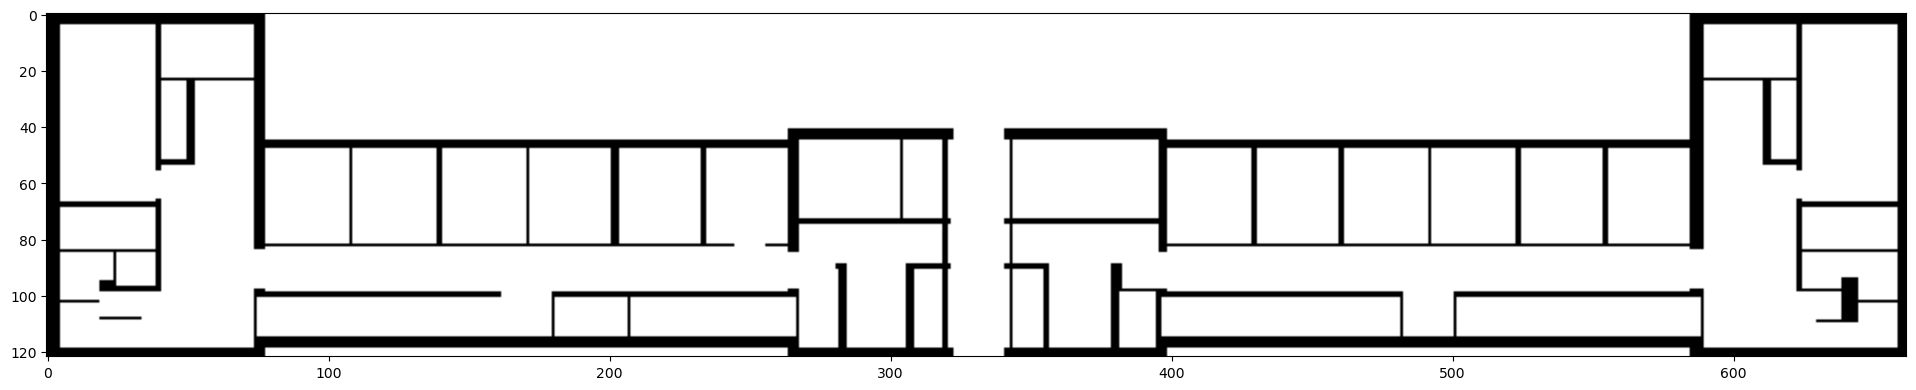

In [213]:
plt.figure(figsize=(24,16))
plt.imshow(map_eg, cmap='gray')

plt.show()

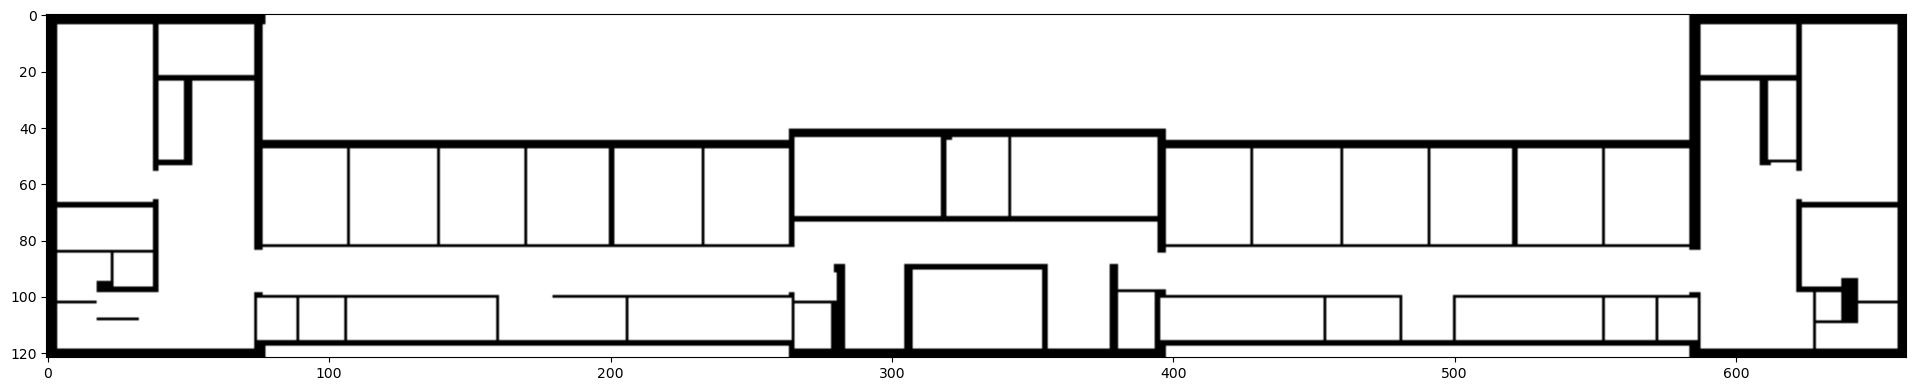

In [214]:
plt.figure(figsize=(24,16))
plt.imshow(map_og1, cmap='gray')

plt.show()

### Visualisierung der vorliegenden Daten

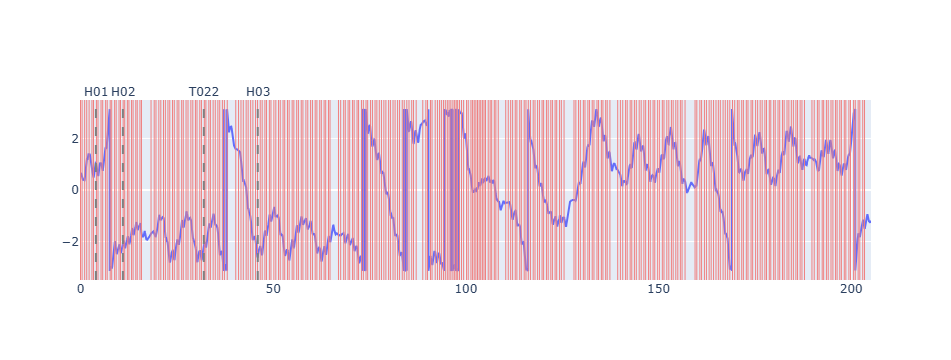

In [215]:
fig=go.Figure()

fig.add_trace(
    go.Scatter(
        x=df_heading['t_sec'],
        y=df_heading['heading_rad'],
        mode='lines',
        name='Yaw'
    )
)

for x in df_steps['t_sec']:
    fig.add_vline(
        x=x,
        line_color='lightcoral',
        line_width=1
    )

markers_r1 = {4: 'H01', 11: 'H02', 32: 'T022', 46: 'H03'}
markers_r2 = {18: 'H03', 52: 'H13', 78: 'H12', 93: 'H11', 116: 'H01', 123: 'H02'}

for x, label in markers_r1.items():
    fig.add_vline(
        x=x,
        line_dash='dash',
        line_color='gray',
        annotation_text=label,
        annotation_position='top'
    )
    
fig.show()

## Kpmbination von df_steps und df_heading

Für jeden Schritt wird das Heading übernommen und in einer neuen Spalte heading_rad eingetragen

In [216]:
df_steps.head(5)

,id,run_id,timestamp_ms,accel_norm,compass_deg,t_sec
0,395,R3,1781615348028,11.886300,156.093642,0.000
1,396,R3,1781615348436,13.683437,129.472460,0.408
2,397,R3,1781615349108,13.199086,97.981503,1.080
3,398,R3,1781615349644,12.269263,46.766772,1.616
4,399,R3,1781615350261,12.692106,44.515823,2.233


In [217]:
df_steps = df_steps.drop(columns='heading_rad', errors='ignore') # drop heading_rad if already exists

df_steps = pd.merge_asof(
    df_steps,
    df_heading[['t_sec', 'heading_rad']],
    on='t_sec',
    direction='nearest'
)
df_steps.head(5)

,id,run_id,timestamp_ms,accel_norm,compass_deg,t_sec,heading_rad
0,395,R3,1781615348028,11.886300,156.093642,0.000,0.608923
1,396,R3,1781615348436,13.683437,129.472460,0.408,0.522946
2,397,R3,1781615349108,13.199086,97.981503,1.080,0.400481
3,398,R3,1781615349644,12.269263,46.766772,1.616,1.225383
4,399,R3,1781615350261,12.692106,44.515823,2.233,1.357017


## PDR

In [218]:
step_length = 0.60
add = math.pi/2
df_steps['dx'] = step_length * np.cos(df_steps.heading_rad + add)
df_steps['dy'] = step_length * np.sin(df_steps.heading_rad + add)

df_steps['x'] = 74 + df_steps['dx'].cumsum()
df_steps['y'] = 16 + df_steps['dy'].cumsum()

df_steps.head(5)

,id,run_id,timestamp_ms,accel_norm,compass_deg,t_sec,heading_rad,dx,dy,x,y
0,395,R3,1781615348028,11.886300,156.093642,0.000,0.608923,-0.343190,0.492159,73.656810,16.492159
1,396,R3,1781615348436,13.683437,129.472460,0.408,0.522946,-0.299661,0.519811,73.357149,17.011970
2,397,R3,1781615349108,13.199086,97.981503,1.080,0.400481,-0.233917,0.552524,73.123232,17.564494
3,398,R3,1781615349644,12.269263,46.766772,1.616,1.225383,-0.564561,0.203152,72.558671,17.767646
4,399,R3,1781615350261,12.692106,44.515823,2.233,1.357017,-0.586342,0.127293,71.972329,17.894939


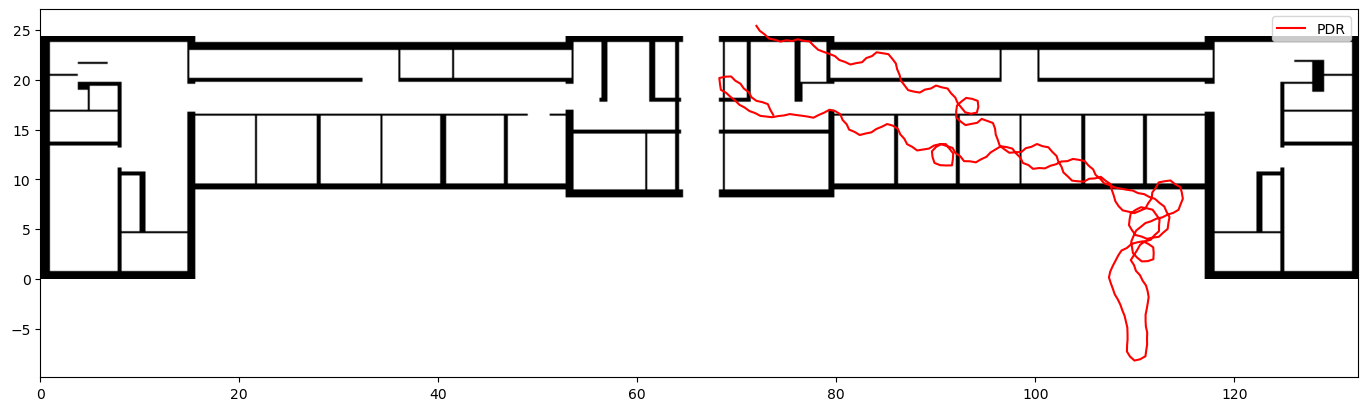

In [219]:
res = 0.2
ny, nx = map_eg.shape

fig, ax = plt.subplots(figsize=(17, 10))

ax.imshow(
    map_eg,
    cmap='gray',
    origin='lower',
    extent=[0, nx * res, 0, ny * res]
)

ax.plot(df_steps.iloc[:-10]['x'], df_steps.iloc[:-10]['y'], label='PDR', color='red')

ax.set_aspect('equal')
ax.legend()
plt.show()